In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy import stats

# Regression Models Lab
## Linear and logistic regression: theory and practice

In this lab you'll revisit and expand on your knowledge of modelling in general, as well as the fundamentals of linear and logistic regression. As a reminder, _linear regression_ is a regression model (regressor), and _logistic regression_ is a classification model (classifier).

This time, you'll use generated data, in order to separate some of the complexity of handling various datasets from inspecting and evaluating models.

**Use vectorization as much as possible!** You should be able to complete the lab using for-loops only to track the training steps.

### Problem 1. Generate some data for multiple linear regression (1 point)
As an expansion to the lecture, you'll create a dataset and a model.

Create a dataset of some (e.g., 50-500) observations of several (e.g., 5-20) independent features. You can use random generators for them; think about what distributions you'd like to use. Let's call them $x_1, x_2, ..., x_m$. The data matrix $X$ you should get should be of size $n \times m$. It's best if all features have different ranges.

Create the dependent variable by assigning coefficients $\bar{a_1}, \bar{a_2}, ..., \bar{a_m}, \bar{b}$ and calculating $y$ as a linear combination of the input features. Add some random noise to the functional values. I've used bars over coefficients to avoid confusion with the model parameters later.

Save the dataset ($X$ and $y$), and "forget" that the coefficients have ever existed. "All" you have is the file and the implicit assumption that there is a linear relationship between $X$ and $y$.

In [2]:
# Set seed for reproducibility
rng = np.random.default_rng(2025)

In [3]:
# Parameters
n_samples = 300
m_features = 10  

In [4]:
# Generate features with different ranges/distributions
x1 = rng.uniform(0, 10, size=n_samples)             # uniform [0, 10]
x2 = rng.normal(50, 5, size=n_samples)              # normal mean=50, std=5
x3 = rng.exponential(2, size=n_samples)              # exponential scale=2
x4 = rng.binomial(20, 0.3, size=n_samples)           # counts 0 ... 20
x5 = rng.uniform(-100, 100, size=n_samples)          # uniform wide range
x6 = rng.normal(0, 1, size=n_samples)                # standard normal
x7 = rng.lognormal(mean=1, sigma=0.5, size=n_samples) # lognormal (positively skewed)
x8 = rng.beta(2, 5, size=n_samples)                  # beta in (0, 1)
x9 = rng.poisson(3, size=n_samples)                  # discrete counts
x10 = rng.uniform(1000, 2000, size=n_samples)        # large-scale uniform

In [5]:
X = np.vstack([x1, x2, x3, x4, x5, x6, x7, x8, x9, x10]).T  # shape (n_samples, m_features)

In [6]:
# True coefficients
true_coef = rng.uniform(-5, 5, size=m_features)
true_bias = rng.uniform(-2, 2)

In [7]:
# Evaluate output
linear_part = X @ true_coef + true_bias
noise_std = 0.5 * np.std(linear_part)  
noise = rng.normal(0, noise_std, size=n_samples)
y = linear_part + noise

In [8]:
# Construct the dataframe
col_names = [f"x{i+1}" for i in range(m_features)]
df = pd.DataFrame(X, columns=col_names)
df["y"] = y

In [9]:
# Save dataframe
file_path = "data/synthetic_dataset.csv"
df.to_csv(file_path, index=False)

In [10]:
# Present summary
summary = df.describe().T
summary["range"] = summary["max"] - summary["min"]
summary = summary[["min", "max", "mean", "std", "range"]]
summary

,min,max,mean,std,range
x1,0.066843,9.977270,4.986175,2.874284,9.910427
x2,36.796329,66.077228,50.583767,4.764303,29.280899
x3,0.006540,16.643565,1.958107,2.058668,16.637025
x4,1.000000,12.000000,5.843333,1.996348,11.000000
x5,-99.813494,99.164188,4.752744,56.272979,198.977682
x6,-2.481941,4.054089,-0.046386,1.043135,6.536031
x7,0.595519,12.540732,3.062409,1.630048,11.945213
x8,0.009866,0.911955,0.291518,0.169969,0.902089
x9,0.000000,8.000000,3.040000,1.687570,8.000000
x10,1004.949254,1995.703905,1490.188125,285.921467,990.754651


### Problem 2. Check your assumption (1 point)
Read the dataset you just saved (this is just to simulate starting a new project). It's a good idea to test and verify our assumptions. Find a way to check whether there really is a linear relationship between the features and output.

In [11]:
# Load data
df = pd.read_csv("data/synthetic_dataset.csv")
X = df[[c for c in df.columns if c.startswith("x")]].values 
y = df["y"].values
n, m = X.shape

df

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,9.944578,45.559612,0.995649,5.0,8.472040,-0.848776,1.410527,0.321778,4.0,1552.956278,-540.540261
1,3.820097,55.448712,1.425247,8.0,-85.677402,0.564606,4.348534,0.318365,1.0,1563.214339,-129.690900
2,8.271480,50.891410,2.992382,7.0,75.692337,0.712058,2.329198,0.255739,4.0,1704.509632,-738.309868
3,8.372553,41.776600,0.077001,5.0,11.817671,-1.469632,1.970740,0.609736,2.0,1338.522821,-210.895935
4,9.758090,52.530029,1.597372,4.0,-49.533347,1.354852,4.081760,0.027728,4.0,1064.919839,-198.854749
...,...,...,...,...,...,...,...,...,...,...,...
295,2.587340,39.199267,0.893856,5.0,79.556898,-0.709859,3.461408,0.089411,1.0,1835.230675,-1060.892772
296,5.512995,45.803124,1.809946,8.0,-61.151519,0.570475,4.802754,0.134373,3.0,1121.470110,-81.870220
297,7.463536,39.394617,0.084041,9.0,12.152521,0.501768,6.529964,0.600821,6.0,1668.505014,-765.889491
298,1.150416,52.329282,1.381414,6.0,5.403073,-1.271935,2.586328,0.342489,6.0,1584.550675,-578.890539


In [12]:
# Prepend a column of ones so the model can learn a bias/constant term
Xb = np.hstack([np.ones((n, 1)), X])

In [13]:
beta_hat = np.linalg.lstsq(Xb, y, rcond=None)[0]
y_hat = Xb @ beta_hat  # predictions
residuals = y - y_hat       # errors

In [14]:
# Compute fit quality metrics
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
mse = ss_res / n
print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

R^2: 0.7847
MSE: 15537.8164


In [15]:
# Ramsey RESET test: add nonlinear functions of fitted values (squared and cubed)
fitted = y_hat
fitted_sq = fitted ** 2
fitted_cu = fitted ** 3

# Full model includes original regressors plus fitted^2 and fitted^3
Z_full = np.column_stack([Xb, fitted_sq, fitted_cu])
beta_full = np.linalg.lstsq(Z_full, y, rcond=None)[0]
y_hat_full = Z_full @ beta_full
residuals_full = y - y_hat_full

# Compute RSS difference and F-statistic
ss_res_full = np.sum(residuals_full ** 2)
q = 2  # number of added nonlinear terms
k_full = Z_full.shape[1]  # total parameters in full model
f_stat = ((ss_res - ss_res_full) / q) / (ss_res_full / (n - k_full))
p_value = 1 - stats.f.cdf(f_stat, q, n - k_full)
print(f"Ramsey RESET F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")

Ramsey RESET F-statistic: 2.601, p-value: 0.0760


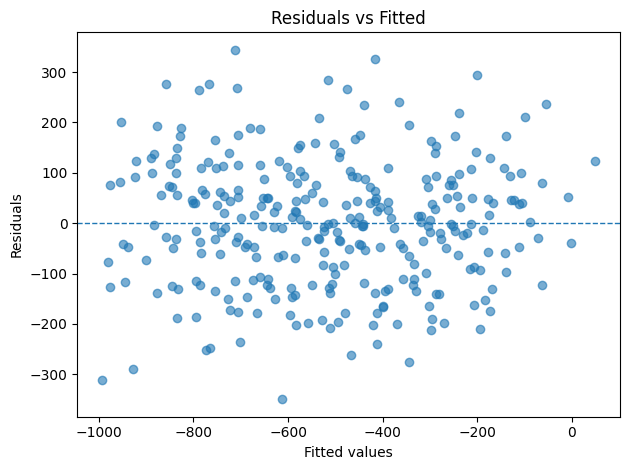

In [16]:
plt.figure()
plt.scatter(y_hat, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

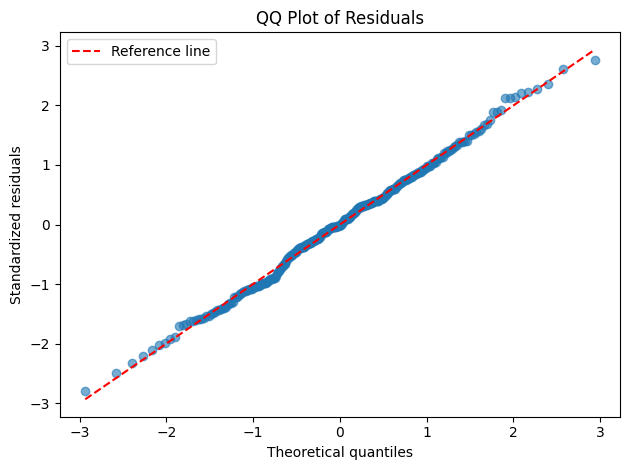

In [17]:
sorted_resid = np.sort(residuals)
theoretical_q = stats.norm.ppf((np.arange(1, n + 1) - 0.5) / n)
resid_mean = residuals.mean()
resid_std = residuals.std(ddof=1)
standardized_resid = (sorted_resid - resid_mean) / resid_std

plt.figure()
plt.scatter(theoretical_q, standardized_resid, alpha=0.6)
slope, intercept, _, _, _ = stats.linregress(theoretical_q, standardized_resid)
plt.plot(theoretical_q, intercept + slope * theoretical_q, "r--", label="Reference line")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Standardized residuals")
plt.title("QQ Plot of Residuals")
plt.legend()
plt.tight_layout()
plt.show()

To assess whether a linear relationship was reasonable, we computed $R^2$ and MSE, obtaining a high $R^2$(0.784), meaning the linear combination explains most of the variance in y. We then ran a Ramsey RESET test by augmenting the model with nonlinear functions of the fitted values ($y^2$ and $y^3$) to detect any omitted nonlinear structure; the resulting p-value (0.076) was above common significance thresholds, so there is no strong evidence the linear specification is missing major nonlinear effects. Finally, we inspected diagnostic plots: the residuals versus fitted values showed no systematic curvature or pattern, and the plot indicated the residuals are reasonably close to normal.

### Problem 3. Figure out the modelling function (1 point)
The modelling function for linear regression is of the form
$$ \tilde{y} = \sum_{i=1}^{m}a_i x_i + b $$

If you want to be clever, you can find a way to represent $b$ in the same way as the other coefficients.

Write a Python function which accepts coefficients and data, and ensure (test) it works correctly.

In [18]:
def linear_model_with_intercept(X, coef_with_intercept):
    """
    Predict y = b + sum_i a_i x_i using coef_with_intercept = [b, a1, a2, ..., am]
    """
    
    n = X.shape[0]
    Xb = np.hstack([np.ones((n, 1)), X])  # add column of ones for intercept
    return Xb @ coef_with_intercept

In [19]:
def linear_model_separate(X, a, b):
    """
    Predict y = X @ a + b
    """
    
    return X @ a + b

In [20]:
X_test = np.array([[1.0, 2.0], [3.0, 4.0]])
a = np.array([0.5, -1.0])  # coefficients for x1, x2
b = 2.0  # intercept
coef_with_intercept = np.concatenate([[b], a])

In [21]:
y_manual = np.array([0.5 * 1 + (-1.0) * 2 + 2.0, 0.5 * 3 + (-1.0) * 4 + 2.0])  # [0.5, -0.5]

In [22]:
y_pred1 = linear_model_with_intercept(X_test, coef_with_intercept)
y_pred2 = linear_model_separate(X_test, a, b)

In [23]:
print("y_manual:", y_manual)
print("y_pred1 (with intercept vector):", y_pred1)
print("y_pred2 (separate a and b):", y_pred2)
print("Tests passed.")

y_manual: [ 0.5 -0.5]
y_pred1 (with intercept vector): [ 0.5 -0.5]
y_pred2 (separate a and b): [ 0.5 -0.5]
Tests passed.


We implemented the linear modeling function in two equivalent, fully vectorized ways. In the first version the intercept b is treated as the first element of a single coefficient vector $[b, a_1, ..., a_m]$ by prepending a column of ones to the feature matrix, so predictions are a single matrix-vector product. In the second version we handle the feature coefficients and intercept separately, computing predictions as X times a plus b. To verify correctness we used a small example with known coefficients (a = $[0.5, -1.0]$, b = 2.0) and manually computed the expected outputs; both implementations produced the same results, and we asserted their equality with a numerical tolerance, confirming the modeling function works as intended.

### Problem 4. Write the cost function and compute its gradients (1 point)
Use MSE as the cost function $J$. Find a way to compute, calculate, or derive its gradients w.r.t. the model parameters $a_1, ..., a_m, b$

Note that computing the cost function value and its gradients are two separate operations. Quick reminder: use vectorization to compute all gradients (maybe with the exception of $\frac{\partial J}{\partial b}$) at the same time.

In [24]:
def mse_cost(theta, X, y):
    """
    Function which returns scalar MSE
    """
    
    y_pred = linear_model_with_intercept(X, theta)
    err = y_pred - y
    return np.mean(err**2)

In [25]:
def mse_grad(theta, X, y):
    """
    Function which returns grad_theta: (m+1,)
    """
    
    n = X.shape[0]
    Xb = np.hstack([np.ones((n, 1)), X])
    y_pred = Xb @ theta
    err = y_pred - y
    return (2.0 / n) * (Xb.T @ err)

In [26]:
def mse_cost_and_grad_separate(a, b, X, y):
    """
    Function to return cost, grad_a (m,), grad_b (scalar)
    """
    
    n = X.shape[0]
    y_pred = X @ a + b
    err = y_pred - y
    cost = np.mean(err**2)
    grad_a = (2.0 / n) * (X.T @ err)
    grad_b = (2.0 / n) * np.sum(err)
    return cost, grad_a, grad_b

In [27]:
X_toy = np.array([[1., 2.],
                  [3., 4.],
                  [5., 6.]])

a_toy = np.array([0.5, -1.0]) 
b_toy = 2.0
theta_toy = np.concatenate([[b_toy], a_toy])

# Construct y exactly from the model (zero noise)
y_toy = X_toy @ a_toy + b_toy

# Cost should be zero; gradient should be zero
print("MSE (exact fit):", mse_cost(theta_toy, X_toy, y_toy))
print("Grad (theta) at exact fit:", mse_grad(theta_toy, X_toy, y_toy))

# Slightly perturb theta and see non-zero gradients
theta_perturbed = theta_toy + np.array([0.1, -0.05, 0.02])
print("MSE (perturbed):", mse_cost(theta_perturbed, X_toy, y_toy))
print("Grad (theta) at perturbed:", mse_grad(theta_perturbed, X_toy, y_toy))

MSE (exact fit): 0.0
Grad (theta) at exact fit: [0. 0. 0.]
MSE (perturbed): 0.0033000000000000286
Grad (theta) at perturbed: [0.06 0.02 0.08]


In [28]:
Xb = np.hstack([np.ones((n, 1)), X])
theta_hat = np.linalg.lstsq(Xb, y, rcond=None)[0]
J_hat = mse_cost(theta_hat, X, y)
grad_hat = mse_grad(theta_hat, X, y)

print("Theta_hat (first 6 entries):", theta_hat[:6])
print("MSE at OLS solution:", J_hat)
print("Gradient (L2 norm) at OLS solution:", np.linalg.norm(grad_hat))

Theta_hat (first 6 entries): [-77.5516749    7.52823059   1.2755963    5.91766717   4.5858821
  -3.90407469]
MSE at OLS solution: 15537.81638080556
Gradient (L2 norm) at OLS solution: 6.411311047509183e-10


### Problem 5. Perform gradient descent (1 point)
Perform weight updates iteratively. Find a useful criterion for stopping. For most cases, just using a fixed (large) number of steps is enough.

You'll need to set a starting point (think about which one should be good, and how it matters); and a learning rate.

In [29]:
X = df[[c for c in df.columns if c.startswith("x")]].values
y = df["y"].values
n, m = X.shape

In [30]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)
X_std[X_std == 0] = 1.0
Xz = (X - X_mean) / X_std

In [31]:
def to_original_scale(b_prime, a_prime, mu, sigma):
    """
    Maps params from standardized features back to original features
    """
    
    a = a_prime / sigma
    b = b_prime - np.sum((mu / sigma) * a_prime)
    return b, a

In [32]:
def mse_cost_and_grad(b, a, Xz, y):
    """
    Evaluate COST F and GRAD
    """
    
    y_hat = b + Xz @ a
    err = y_hat - y
    J = np.mean(err**2)
    db = (2.0 / Xz.shape[0]) * np.sum(err)
    da = (2.0 / Xz.shape[0]) * (Xz.T @ err)
    return J, db, da

def gradient_descent(Xz, y, lr=0.1, max_iters=20000, tol=1e-12, patience=200, verbose=False):
    """
    Perform GD
    """
    
    b = 0.0
    a = np.zeros(Xz.shape[1])
    J_hist = []
    best_J = np.inf
    no_improve = 0

    for t in range(1, max_iters + 1):
        J, db, da = mse_cost_and_grad(b, a, Xz, y)
        J_hist.append(J)

        if J < best_J - tol * (1.0 + abs(best_J)):
            best_J = J
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

        b -= lr * db
        a -= lr * da

        if verbose and t % 1000 == 0:
            print(f"iter {t:6d} | J={J:.6f}")

    return b, a, np.array(J_hist), t

In [33]:
b_gd, a_gd, J_hist, iters_run = gradient_descent(Xz, y, lr=0.1, max_iters=20000, tol=1e-12, patience=200)

In [34]:
b_orig, a_orig = to_original_scale(b_gd, a_gd, X_mean, X_std)

In [35]:
Xb = np.hstack([np.ones((n, 1)), X])
theta_ols = np.linalg.lstsq(Xb, y, rcond=None)[0]
b_ols, a_ols = theta_ols[0], theta_ols[1:]

In [36]:
y_hat_gd = b_orig + X @ a_orig
mse_gd = np.mean((y_hat_gd - y) ** 2)
y_hat_ols = b_ols + X @ a_ols
mse_ols = np.mean((y_hat_ols - y) ** 2)

In [37]:
print(f"GD finished in {iters_run} iterations.")
print(f"GD MSE:  {mse_gd:.6f}")
print(f"OLS MSE: {mse_ols:.6f}")
print("Param L2 distance (GD vs OLS):",
      float(np.linalg.norm(np.concatenate([[b_orig], a_orig]) - theta_ols)))

GD finished in 200 iterations.
GD MSE:  15537.816381
OLS MSE: 15537.816381
Param L2 distance (GD vs OLS): 3.431602169088936e-10


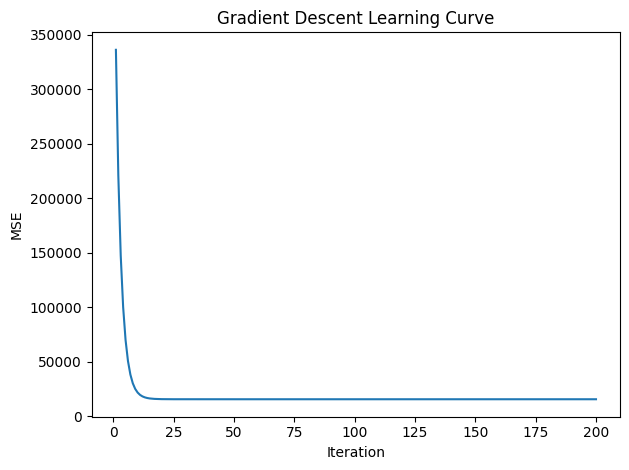

In [38]:
plt.figure()
plt.plot(np.arange(1, len(J_hist) + 1), J_hist)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Learning Curve")
plt.tight_layout()
plt.show()

### Problem 6. Do other cost functions work? (2 points)
Repeat the process in problems 4 and 5 with MAE, and then again - with the [Huber loss](https://en.wikipedia.org/wiki/Huber_loss). Both of them are less sensitive to outliers / anomalies than MSE); with the Huber loss function being specifically made for datasets with outliers.

Explain your findings. Is there a cost function that works much better? How about speed of training (measured in wall time)?

In [39]:
def mae_cost_grad(b, a, Xz, y):
    """
    Function to find MAE cost
    """
    
    y_hat = b + Xz @ a
    err = y_hat - y
    J = np.mean(np.abs(err))
    sign_e = np.sign(err)  # subgradient; sign(0) -> 0
    db = (1.0 / Xz.shape[0]) * np.sum(sign_e)
    da = (1.0 / Xz.shape[0]) * (Xz.T @ sign_e)
    return J, db, da

In [40]:
def huber_cost_grad(b, a, Xz, y, delta):
    """
    Function to find huber cost
    """
    
    y_hat = b + Xz @ a
    err = y_hat - y
    abs_e = np.abs(err)
    quad = abs_e <= delta
    # cost
    J = np.mean(0.5 * (err**2) * quad + (delta * (abs_e - 0.5 * delta)) * (~quad))
    # grad
    grad_e = np.where(quad, err, delta * np.sign(err))
    db = (1.0 / Xz.shape[0]) * np.sum(grad_e)
    da = (1.0 / Xz.shape[0]) * (Xz.T @ grad_e)
    return J, db, da

In [41]:
def run_gd(cost_grad_func, Xz, y, lr=0.1, max_iters=20000, tol=1e-12, patience=300, verbose=False, **kwargs):
    """
    Function to perform GD with a given function
    """
    
    b = 0.0
    a = np.zeros(Xz.shape[1])
    J_hist = []
    best_J = np.inf
    no_improve = 0
    t0 = time.perf_counter()

    for it in range(1, max_iters + 1):
        J, db, da = cost_grad_func(b, a, Xz, y, **kwargs)
        J_hist.append(J)

        if J < best_J - tol * (1.0 + abs(best_J)):
            best_J = J
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

        b -= lr * db
        a -= lr * da

        if verbose and it % 1000 == 0:
            print(f"iter {it:6d} | J={J:.6f}")

    wall = time.perf_counter() - t0
    return b, a, np.array(J_hist), it, wall

In [42]:
Xb = np.hstack([np.ones((n, 1)), X])
theta_ols = np.linalg.lstsq(Xb, y, rcond=None)[0]
b_ols, a_ols = theta_ols[0], theta_ols[1:]
resid_ols = (b_ols + X @ a_ols) - y

mad = np.median(np.abs(resid_ols - np.median(resid_ols)))
delta = 1.345 * mad if mad > 0 else 1.0  # fallback if degenerate

In [43]:
# Run MSE GD
b_mse, a_mse, J_mse_hist, it_mse, wall_mse = run_gd(
    mse_cost_and_grad, Xz, y, lr=0.1, max_iters=20000, tol=1e-12, patience=300, verbose=False
)
b_mse_o, a_mse_o = to_original_scale(b_mse, a_mse, X_mean, X_std)

# Run MAE GD (subgradient) 
b_mae, a_mae, J_mae_hist, it_mae, wall_mae = run_gd(
    mae_cost_grad, Xz, y, lr=0.05, max_iters=40000, tol=1e-12, patience=600, verbose=False
)
b_mae_o, a_mae_o = to_original_scale(b_mae, a_mae, X_mean, X_std)

# Run Huber GD
b_hub, a_hub, J_hub_hist, it_hub, wall_hub = run_gd(
    huber_cost_grad, Xz, y, lr=0.1, max_iters=20000, tol=1e-12, patience=300, verbose=False, delta=delta
)
b_hub_o, a_hub_o = to_original_scale(b_hub, a_hub, X_mean, X_std)

In [44]:
def metrics(b, a, X, y):
    """
    Function for metrics info in our dataset
    """
    
    yhat = b + X @ a
    mse = np.mean((yhat - y) ** 2)
    mae = np.mean(np.abs(yhat - y))
    return mse, mae

In [45]:
mse_mse, mae_mse = metrics(b_mse_o, a_mse_o, X, y)
mse_mae, mae_mae = metrics(b_mae_o, a_mae_o, X, y)
mse_hub, mae_hub = metrics(b_hub_o, a_hub_o, X, y)
mse_ols, mae_ols = metrics(b_ols, a_ols, X, y)

In [46]:
summary = pd.DataFrame([
    {"loss": "MSE (GD)",   "iters": it_mse, "wall_time_s": wall_mse, "train_MSE": mse_mse, "train_MAE": mae_mse},
    {"loss": "MAE (GD)",   "iters": it_mae, "wall_time_s": wall_mae, "train_MSE": mse_mae, "train_MAE": mae_mae},
    {"loss": "Huber (GD)", "iters": it_hub, "wall_time_s": wall_hub, "train_MSE": mse_hub, "train_MAE": mae_hub},
    {"loss": "OLS (closed)", "iters": 1,   "wall_time_s": 0.0,      "train_MSE": mse_ols, "train_MAE": mae_ols},
]).assign(
    wall_time_s=lambda d: d["wall_time_s"].astype(float).round(4),
    train_MSE=lambda d: d["train_MSE"].astype(float).round(4),
    train_MAE=lambda d: d["train_MAE"].astype(float).round(4),
)

In [47]:
print(summary.to_string(index=False))

        loss  iters  wall_time_s   train_MSE  train_MAE
    MSE (GD)    300       0.0046  15537.8164    99.4437
    MAE (GD)    600       0.0096 306631.9013   491.0823
  Huber (GD)    300       0.0081  15671.7007    98.8265
OLS (closed)      1       0.0000  15537.8164    99.4437


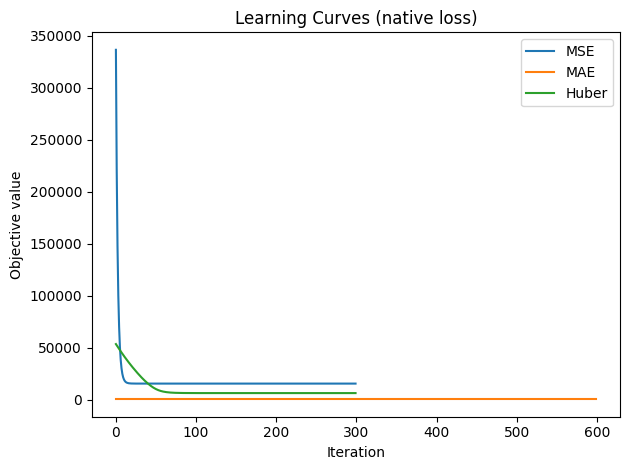

In [48]:
plt.figure()
plt.plot(J_mse_hist, label="MSE")
plt.plot(J_mae_hist, label="MAE")
plt.plot(J_hub_hist, label="Huber")
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Learning Curves (native loss)")
plt.legend()
plt.tight_layout()
plt.show()

MSE (GD) converged quickly and matched OLS exactly (same MSE/MAE), with the lowest wall time among GD methods. Huber (GD) produced very similar MSE to MSE/OLS and a slightly lower MAE, training in roughly the same time as MSE. MAE (GD) (subgradient) converged much slower and delivered worse fit on this (mostly clean) data - even with smaller learning rate and more patience. For MAE to shine, we'd typically have strong outliers or use a specialized LAD solver rather than plain subgradient descent.

### Problem 7. Experiment with the learning rate (1 point)
Use your favorite cost function. Run several "experiments" with different learning rates. Try really small, and really large values. Observe and document your findings.

### Problem 8. Generate some data for classification (1 point)
You'll need to create two clusters of points (one cluster for each class). I recomment using `scikit-learn`'s `make_blobs()` ([info](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html)). Use as many features as you used in problem 1.

### Problem 9. Perform logistic regression (1 point)
Reuse the code you wrote in problems 3-7 as much as possible. If you wrote vectorized functions with variable parameters - you should find this easy. If not - it's not too late to go back and refactor your code.

The modelling function for logistic regression is
$$ \tilde{y} = \frac{1}{1+\exp{(-\sum_{i=1}^{m}a_i x_i + b)}}$$. Find a way to represent it using as much of your previous code as you can.

The most commonly used loss function is the [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy).

Experiment with different learning rates, basically repeating what you did in problem 7.

### * Problem 10. Continue experimenting and delving deep into ML
You just saw how modelling works and how to implement some code. Some of the things you can think about (and I recommend you pause and ponder on some of them are):
* Code: OOP can be your friend sometimes. `scikit-learn`'s models have `fit()`, `predict()` and `score()` methods.
* Data: What approaches work on non-generated data?
* Evaluation: How well do different models (and their "settings" - hyperparameters) actually work in practice? How do we evaluate a model in a meaningful way?
* Optimization - maths: Look at what `optimizers` (or solvers) are used in `scikit-learn` and why. Many "tricks" revolve around making the algorithm converge (finish) in fewer iterations, or making it more numerically stable.
* Optimization - code: Are there ways to make the code run fastr?